# BraTS Preprocessing for MMSK 3D U-Net

**Output Format:**
- File: `.npz` dengan keys `images` dan `seg`
- `images`: shape `[4, D, H, W]` - T1, T2, FLAIR, T1ce (dalam urutan ini!)
- `seg`: shape `[D, H, W]` - Label 0,1,2,3

**Preprocessing Steps:**
1. Load 4 modalities (T1, T2, FLAIR, T1ce)
2. Z-score normalization per modality (non-zero voxels)
3. Crop non-zero region
4. Pad/Resize to 128×128×128
5. Save as .npz

**Note:** Tidak ada split data - BraTS sudah menyediakan training data terpisah

In [3]:
%pip install -r requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from scipy import ndimage

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Configuration

In [5]:
# Paths
DATA_DIR = Path("/home/mci/arsyadl/braTS/training_data1_v2")
OUTPUT_DIR = Path("/home/mci/arsyadl/braTS/preprocessed")
OUTPUT_DIR.mkdir(exist_ok=True)

# Target size (sesuai paper)
TARGET_SIZE = (128, 128, 128)

# Modality order (PENTING! Harus sesuai dengan model)
# Model expects: [T1, T2, FLAIR, T1ce]
MODALITY_ORDER = ['t1n', 't2w', 't2f', 't1c']  # T1, T2, FLAIR, T1ce
MODALITY_NAMES = ['T1', 'T2', 'FLAIR', 'T1ce']

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Target size: {TARGET_SIZE}")
print(f"Modality order: {MODALITY_NAMES}")

Data directory: /home/mci/arsyadl/braTS/training_data1_v2
Output directory: /home/mci/arsyadl/braTS/preprocessed
Target size: (128, 128, 128)
Modality order: ['T1', 'T2', 'FLAIR', 'T1ce']


## 2. Explore Dataset

In [6]:
# Get all folders
folders = sorted([f for f in DATA_DIR.iterdir() if f.is_dir()])
print(f"Total folders: {len(folders)}")

# Check first folder
if folders:
    sample_folder = folders[0]
    print(f"\nSample folder: {sample_folder.name}")
    print("Files:")
    for f in sorted(sample_folder.iterdir()):
        print(f"  - {f.name}")

Total folders: 1350

Sample folder: BraTS-GLI-00005-100
Files:
  - BraTS-GLI-00005-100-seg.nii.gz
  - BraTS-GLI-00005-100-t1c.nii.gz
  - BraTS-GLI-00005-100-t1n.nii.gz
  - BraTS-GLI-00005-100-t2f.nii.gz
  - BraTS-GLI-00005-100-t2w.nii.gz


In [35]:
# Count folders with segmentation
valid_folders = []
for folder in folders:
    seg_file = folder / f"{folder.name}-seg.nii.gz"
    if seg_file.exists():
        valid_folders.append(folder)

print(f"Folders with segmentation: {len(valid_folders)}")
print(f"Folders without segmentation: {len(folders) - len(valid_folders)}")

Folders with segmentation: 1350
Folders without segmentation: 0


## 3. Load Sample Data

In [8]:
# Load one sample
sample_folder = valid_folders[0]
folder_name = sample_folder.name

print(f"Loading sample: {folder_name}")

# Load modalities in correct order
images = []
for mod in MODALITY_ORDER:
    file_path = sample_folder / f"{folder_name}-{mod}.nii.gz"
    nii = nib.load(str(file_path))
    img = nii.get_fdata().astype(np.float32)
    images.append(img)
    print(f"  {mod}: shape {img.shape}, min={img.min():.2f}, max={img.max():.2f}")

# Load segmentation
seg_path = sample_folder / f"{folder_name}-seg.nii.gz"
seg = nib.load(str(seg_path)).get_fdata().astype(np.uint8)
print(f"  seg: shape {seg.shape}, unique labels: {np.unique(seg)}")

# Stack images
images = np.stack(images, axis=0)  # [4, D, H, W]
print(f"\nStacked images shape: {images.shape}")

Loading sample: BraTS-GLI-00005-100
  t1n: shape (182, 218, 182), min=0.00, max=4300.92
  t2w: shape (182, 218, 182), min=0.00, max=2519.35
  t2f: shape (182, 218, 182), min=0.00, max=1406.90
  t1c: shape (182, 218, 182), min=0.00, max=8183.82
  seg: shape (182, 218, 182), unique labels: [0 2 4]

Stacked images shape: (4, 182, 218, 182)


## 4. Visualize Sample

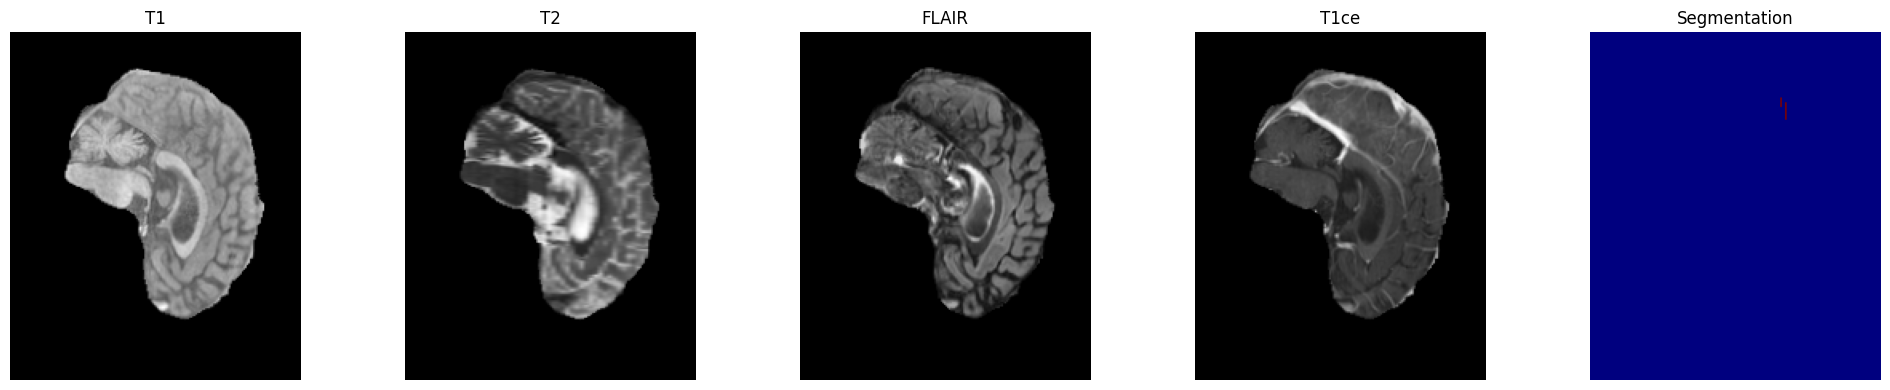

Slice 91 of 182


In [9]:
# Visualize middle slice
slice_idx = images.shape[1] // 2

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, name in enumerate(MODALITY_NAMES):
    axes[i].imshow(images[i, slice_idx, :, :], cmap='gray')
    axes[i].set_title(name)
    axes[i].axis('off')

axes[4].imshow(seg[slice_idx, :, :], cmap='jet')
axes[4].set_title('Segmentation')
axes[4].axis('off')

plt.tight_layout()
plt.show()

print(f"Slice {slice_idx} of {images.shape[1]}")

## 5. Preprocessing Functions

In [36]:
def z_score_normalize(image):
    """
    Z-score normalization per modality (non-zero voxels only)
    """
    mask = image > 0
    if mask.sum() > 0:
        mean = image[mask].mean()
        std = image[mask].std()
        if std > 0:
            image[mask] = (image[mask] - mean) / std
    return image

def crop_nonzero_region(images, seg, margin=5):
    """
    Crop to non-zero region with margin
    """
    # Find non-zero region from all modalities
    mask = np.any(images > 0, axis=0)
    
    # Get bounding box
    coords = np.argwhere(mask)
    if len(coords) == 0:
        return images, seg
    
    z_min, y_min, x_min = coords.min(axis=0)
    z_max, y_max, x_max = coords.max(axis=0)
    
    # Add margin
    z_min = max(0, z_min - margin)
    y_min = max(0, y_min - margin)
    x_min = max(0, x_min - margin)
    z_max = min(images.shape[1], z_max + margin)
    y_max = min(images.shape[2], y_max + margin)
    x_max = min(images.shape[3], x_max + margin)
    
    # Crop
    images_crop = images[:, z_min:z_max, y_min:y_max, x_min:x_max]
    seg_crop = seg[z_min:z_max, y_min:y_max, x_min:x_max]
    
    return images_crop, seg_crop

def resize_to_target(images, seg, target_size=(128, 128, 128)):
    """
    Resize to target size using zoom
    """
    current_size = images.shape[1:]
    zoom_factors = [t / c for t, c in zip(target_size, current_size)]
    
    # Resize images
    images_resized = np.zeros((4, *target_size), dtype=np.float32)
    for i in range(4):
        images_resized[i] = ndimage.zoom(images[i], zoom_factors, order=1)
    
    # Resize segmentation (nearest neighbor)
    seg_resized = ndimage.zoom(seg, zoom_factors, order=0).astype(np.uint8)
    
    return images_resized, seg_resized

print("Preprocessing functions defined!")

Preprocessing functions defined!


## 6. Test Preprocessing on Sample

In [11]:
# Test on sample
print("Original shape:", images.shape, seg.shape)

# 1. Normalize
images_norm = images.copy()
for i in range(4):
    images_norm[i] = z_score_normalize(images_norm[i])
print("After normalization:", images_norm.shape)

# 2. Crop
images_crop, seg_crop = crop_nonzero_region(images_norm, seg)
print("After cropping:", images_crop.shape, seg_crop.shape)

# 3. Resize
images_final, seg_final = resize_to_target(images_crop, seg_crop, TARGET_SIZE)
print("After resizing:", images_final.shape, seg_final.shape)

# Check statistics
for i, name in enumerate(MODALITY_NAMES):
    mask = images_final[i] != 0
    if mask.sum() > 0:
        print(f"{name}: mean={images_final[i][mask].mean():.3f}, std={images_final[i][mask].std():.3f}")

Original shape: (4, 182, 218, 182) (182, 218, 182)
After normalization: (4, 182, 218, 182)
After cropping: (4, 139, 170, 139) (139, 170, 139)
After resizing: (4, 128, 128, 128) (128, 128, 128)
T1: mean=0.000, std=0.878
T2: mean=-0.000, std=0.929
FLAIR: mean=0.000, std=0.893
T1ce: mean=0.000, std=0.872


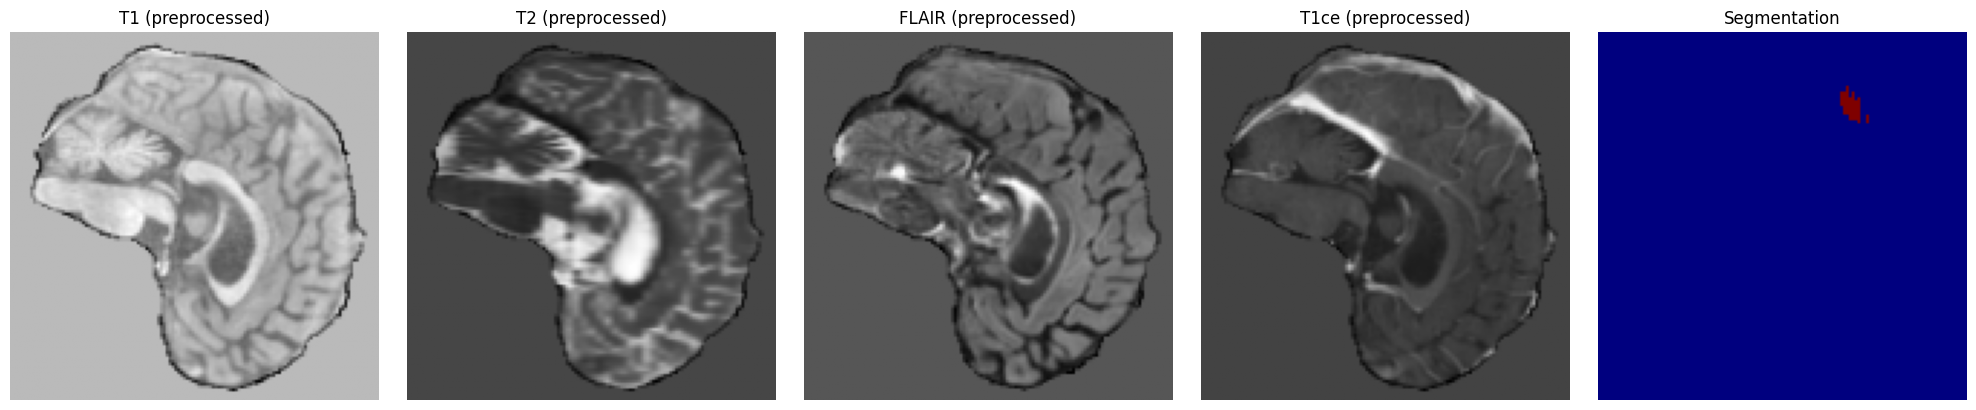

In [12]:
# Visualize preprocessed
slice_idx = TARGET_SIZE[0] // 2

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, name in enumerate(MODALITY_NAMES):
    axes[i].imshow(images_final[i, slice_idx, :, :], cmap='gray')
    axes[i].set_title(f'{name} (preprocessed)')
    axes[i].axis('off')

axes[4].imshow(seg_final[slice_idx, :, :], cmap='jet')
axes[4].set_title('Segmentation')
axes[4].axis('off')

plt.tight_layout()
plt.show()

## 7. Preprocess All Data

In [37]:
def preprocess_sample(folder_path, output_dir, target_size=(128, 128, 128)):
    """
    Preprocess one sample and save as .npz
    """
    folder_name = folder_path.name
    
    try:
        # Load modalities in correct order
        images = []
        for mod in MODALITY_ORDER:
            file_path = folder_path / f"{folder_name}-{mod}.nii.gz"
            if not file_path.exists():
                return False, "Missing modality"
            
            nii = nib.load(str(file_path))
            img = nii.get_fdata().astype(np.float32)
            images.append(img)
        
        # Load segmentation
        seg_path = folder_path / f"{folder_name}-seg.nii.gz"
        if not seg_path.exists():
            return False, "Missing segmentation"
        
        seg = nib.load(str(seg_path)).get_fdata().astype(np.uint8)
        
        # Stack images: [4, D, H, W]
        images = np.stack(images, axis=0)
        
        # Preprocessing
        # 1. Z-score normalization
        for i in range(4):
            images[i] = z_score_normalize(images[i])
        
        # 2. Crop non-zero region
        images, seg = crop_nonzero_region(images, seg)
        
        # 3. Resize to target size
        images, seg = resize_to_target(images, seg, target_size)
        
        # Save as .npz
        output_file = output_dir / f"{folder_name}.npz"
        np.savez_compressed(
            output_file,
            images=images.astype(np.float32),  # [4, D, H, W]
            seg=seg.astype(np.uint8)           # [D, H, W]
        )
        
        return True, "Success"
        
    except Exception as e:
        return False, str(e)

print("Preprocessing function ready!")

Preprocessing function ready!


In [38]:
# Preprocess all data
print(f"Processing {len(valid_folders)} folders...\n")

success_count = 0
failed_count = 0
failed_samples = []

for folder in tqdm(valid_folders, desc="Preprocessing"):
    success, message = preprocess_sample(folder, OUTPUT_DIR, TARGET_SIZE)
    
    if success:
        success_count += 1
    else:
        failed_count += 1
        failed_samples.append((folder.name, message))

print(f"\n{'='*60}")
print(f"Preprocessing Complete!")
print(f"{'='*60}")
print(f"✓ Success: {success_count}")
print(f"✗ Failed: {failed_count}")

if failed_samples:
    print(f"\nFailed samples:")
    for name, msg in failed_samples[:10]:  # Show first 10
        print(f"  - {name}: {msg}")

Processing 1350 folders...



Preprocessing: 100%|██████████| 1350/1350 [34:45<00:00,  1.54s/it]


Preprocessing Complete!
✓ Success: 1349
✗ Failed: 1

Failed samples:
  - BraTS-GLI-02768-101: CRC check failed 0xd954480c != 0x4441fc5d


## 8. Verify Output

In [6]:
# List output files
output_files = sorted(OUTPUT_DIR.glob("*.npz"))
print(f"Total output files: {len(output_files)}")

if output_files:
    print(f"\nFirst 5 files:")
    for f in output_files[:5]:
        print(f"  - {f.name}")

Total output files: 1350

First 5 files:
  - BraTS-GLI-00005-100.npz
  - BraTS-GLI-00005-101.npz
  - BraTS-GLI-00006-100.npz
  - BraTS-GLI-00006-101.npz
  - BraTS-GLI-00008-100.npz


In [7]:
# Verify format of one file
if output_files:
    sample_file = output_files[0]
    print(f"Verifying: {sample_file.name}\n")
    
    data = np.load(sample_file)
    
    print(f"Keys: {list(data.keys())}")
    print(f"\nimages:")
    print(f"  Shape: {data['images'].shape}  (expected: [4, 128, 128, 128])")
    print(f"  Dtype: {data['images'].dtype}  (expected: float32)")
    print(f"  Range: [{data['images'].min():.3f}, {data['images'].max():.3f}]")
    
    print(f"\nseg:")
    print(f"  Shape: {data['seg'].shape}  (expected: [128, 128, 128])")
    print(f"  Dtype: {data['seg'].dtype}  (expected: uint8)")
    print(f"  Unique labels: {np.unique(data['seg'])}  (expected: [0, 1, 2, 3])")
    
    # Check modality order
    print(f"\nModality statistics (non-zero voxels):")
    for i, name in enumerate(MODALITY_NAMES):
        mask = data['images'][i] != 0
        if mask.sum() > 0:
            mean = data['images'][i][mask].mean()
            std = data['images'][i][mask].std()
            print(f"  Channel {i} ({name}): mean={mean:.3f}, std={std:.3f}")
    
    print(f"\n✓ Format is correct!")

Verifying: BraTS-GLI-00005-100.npz

Keys: ['images', 'seg']

images:
  Shape: (4, 128, 128, 128)  (expected: [4, 128, 128, 128])
  Dtype: float32  (expected: float32)
  Range: [-4.012, 9.222]

seg:
  Shape: (128, 128, 128)  (expected: [128, 128, 128])
  Dtype: uint8  (expected: uint8)
  Unique labels: [0 2 4]  (expected: [0, 1, 2, 3])

Modality statistics (non-zero voxels):
  Channel 0 (T1): mean=0.000, std=0.878
  Channel 1 (T2): mean=-0.000, std=0.929
  Channel 2 (FLAIR): mean=0.000, std=0.893
  Channel 3 (T1ce): mean=0.000, std=0.872

✓ Format is correct!


In [17]:
def find_sample_with_all_classes(files, required_classes={0, 1, 2, 3}, max_search=50):
    """
    Cari file .npz pertama yang segmentasinya mengandung semua kelas.
    """
    for f in files[:max_search]:
        data = np.load(f)
        unique = set(np.unique(data['seg']).tolist())
        if required_classes.issubset(unique):
            print(f"✓ Sample terpilih: {f.stem}")
            print(f"  Unique labels: {sorted(unique)}")
            return f, data
    raise ValueError(f"Tidak ada sample dengan semua kelas {required_classes} dalam {max_search} file pertama.")

# Pilih sample sekali, pakai di semua visualisasi
sample_files = output_files  # alias agar konsisten dengan Section 10
SAMPLE_FILE, SAMPLE_DATA = find_sample_with_all_classes(sample_files)

✓ Sample terpilih: BraTS-GLI-00009-100
  Unique labels: [0, 1, 2, 3, 4]


In [20]:
def find_sample_with_all_classes(files, required_classes={0, 1, 2, 3}, max_search=100):
    for f in files[:max_search]:
        data = np.load(f)
        unique = set(np.unique(data['seg']).tolist())
        if required_classes.issubset(unique):
            print(f"✓ Sample terpilih : {f.stem}")
            print(f"  Unique labels   : {sorted(unique)}")
            return f, data
    raise ValueError(f"Tidak ada sample dengan semua kelas {required_classes} dalam {max_search} file pertama.")

def find_best_slice(seg_3d, axis=0, required_classes={0, 1, 2, 3}):
    n = seg_3d.shape[axis]
    for offset in range(n // 2 + 1):
        for idx in [n // 2 - offset, n // 2 + offset]:
            if 0 <= idx < n:
                slc = np.take(seg_3d, idx, axis=axis)
                if required_classes.issubset(set(np.unique(slc).tolist())):
                    return idx
    return n // 2  # fallback

print("✓ Helper functions defined")

✓ Helper functions defined


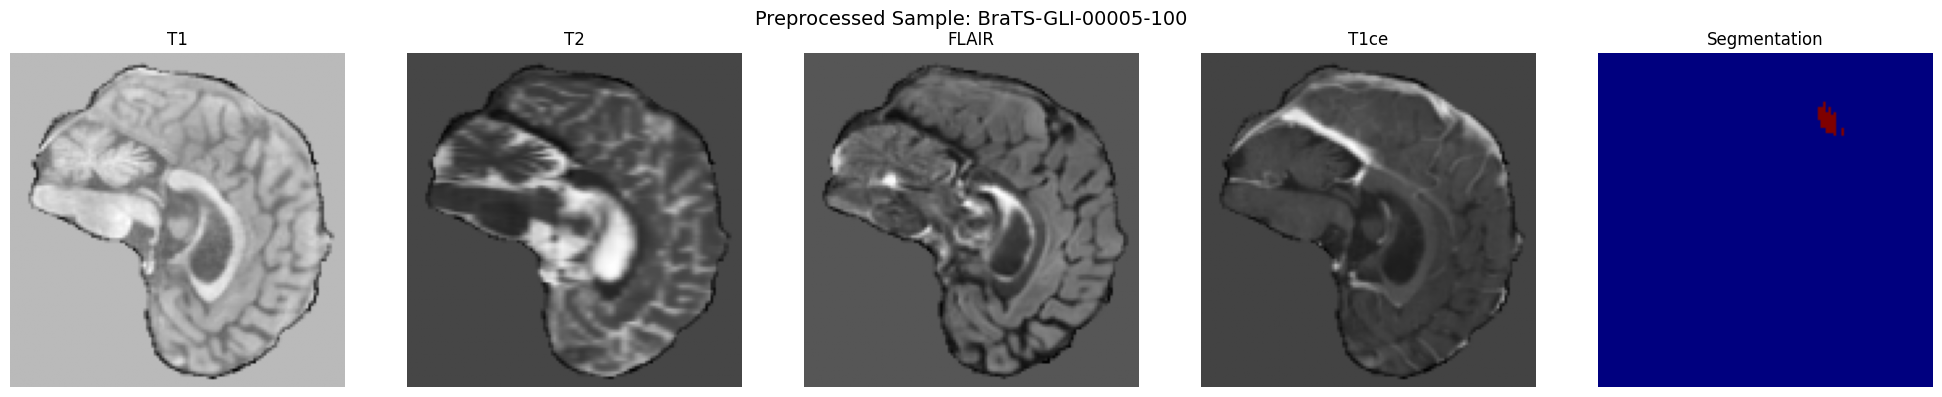

In [18]:
# Visualize one preprocessed sample
if output_files:
    data = np.load(output_files[0])
    images = data['images']
    seg = data['seg']
    
    slice_idx = TARGET_SIZE[0] // 2
    
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    
    for i, name in enumerate(MODALITY_NAMES):
        axes[i].imshow(images[i, slice_idx, :, :], cmap='gray')
        axes[i].set_title(f'{name}')
        axes[i].axis('off')
    
    axes[4].imshow(seg[slice_idx, :, :], cmap='jet')
    axes[4].set_title('Segmentation')
    axes[4].axis('off')
    
    plt.suptitle(f'Preprocessed Sample: {output_files[0].stem}', fontsize=14)
    plt.tight_layout()
    plt.show()

## 9. Preprocess Validation Data

### 9.1 Setup for Validation Data

In [ ]:
# Switch to validation data
DATA_DIR_VAL = Path("/home/mci/arsyadl/braTS/training_data_additional")
OUTPUT_DIR_VAL = Path("/home/mci/arsyadl/braTS/preprocessed_test")
OUTPUT_DIR_VAL.mkdir(exist_ok=True)

print(f"Validation data directory: {DATA_DIR_VAL}")
print(f"Validation output directory: {OUTPUT_DIR_VAL}")

Validation data directory: /home/mci/arsyadl/braTS/training_data_additional
Validation output directory: /home/mci/arsyadl/braTS/preprocessed_test


In [ ]:
# Get validation folders
val_folders = sorted([f for f in DATA_DIR_VAL.iterdir() if f.is_dir()])
print(f"Total validation folders: {len(val_folders)}")

# Count valid folders
valid_val_folders = []
for folder in val_folders:
    seg_file = folder / f"{folder.name}-seg.nii.gz"
    if seg_file.exists():
        valid_val_folders.append(folder)

print(f"Folders with segmentation: {len(valid_val_folders)}")

Total validation folders: 271
Folders with segmentation: 271


### 9.2 Preprocess All Validation Data

In [ ]:
# Preprocess validation data
print(f"Processing {len(valid_val_folders)} validation folders...\n")

val_success = 0
val_failed = 0
val_failed_samples = []

for folder in tqdm(valid_val_folders, desc="Preprocessing Validation"):
    success, message = preprocess_sample(folder, OUTPUT_DIR_VAL, TARGET_SIZE)
    
    if success:
        val_success += 1
    else:
        val_failed += 1
        val_failed_samples.append((folder.name, message))

print(f"\n{'='*60}")
print(f"Validation Preprocessing Complete!")
print(f"{'='*60}")
print(f"✓ Success: {val_success}")
print(f"✗ Failed: {val_failed}")

Processing 271 validation folders...



Preprocessing Validation: 100%|██████████| 271/271 [07:14<00:00,  1.60s/it]


Validation Preprocessing Complete!
✓ Success: 271
✗ Failed: 0


## 10. Visualizations for Paper

### 10.1 Sample Visualization - All Modalities

✓ Saved: results/sample_visualization.png


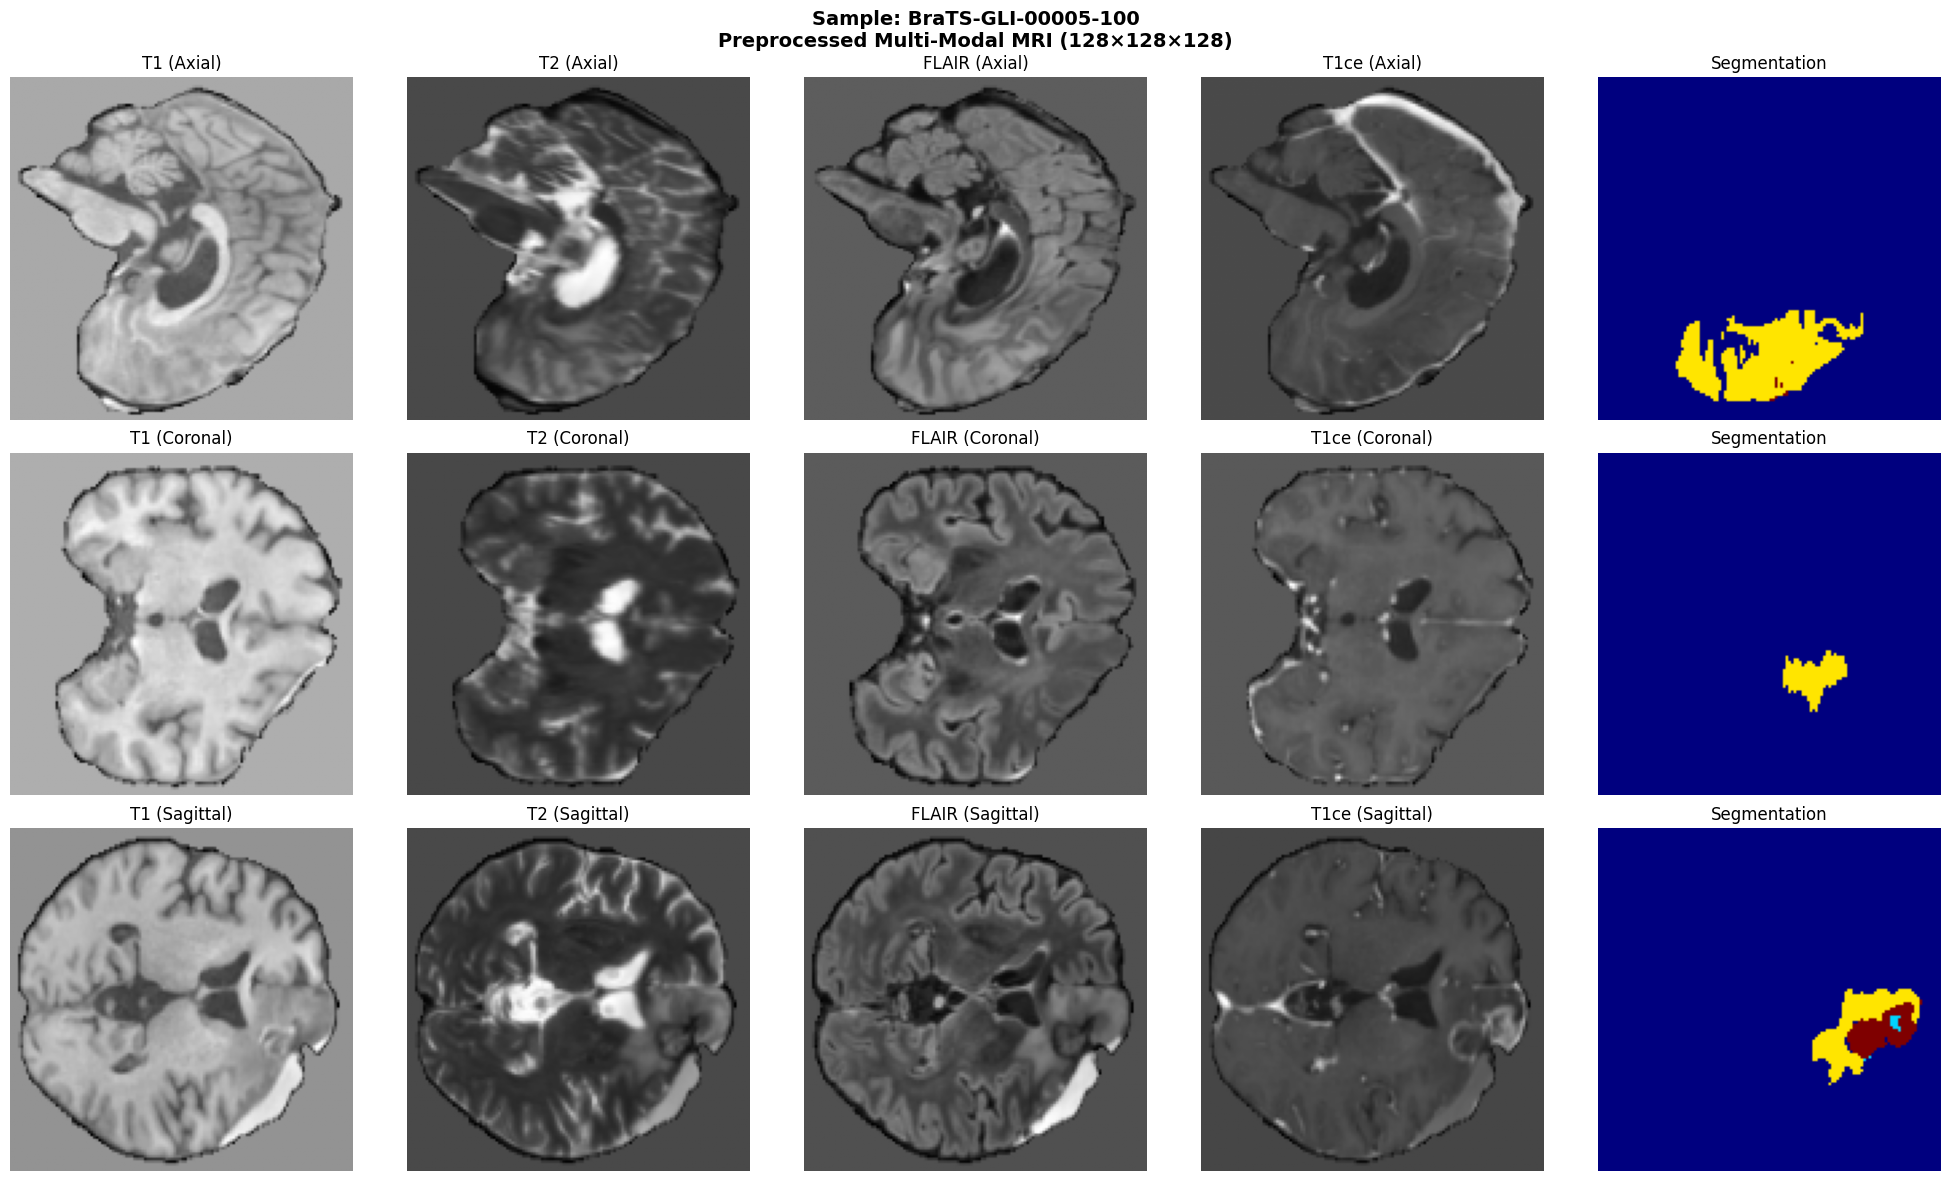

In [21]:
# Load one preprocessed sample
sample_files = sorted(OUTPUT_DIR.glob("*.npz"))
if sample_files:
    # sample_data = np.load(sample_files[0])
    # images = sample_data['images']
    # seg = sample_data['seg']
    images = SAMPLE_DATA['images']
    seg = SAMPLE_DATA['seg']
    
    # Select 3 slices: axial, coronal, sagittal views
    slice_axial = TARGET_SIZE[0] // 2
    slice_coronal = TARGET_SIZE[1] // 2
    slice_sagittal = TARGET_SIZE[2] // 2
    
    fig, axes = plt.subplots(3, 5, figsize=(20, 12))
    
    # Axial view
    for i, name in enumerate(MODALITY_NAMES):
        axes[0, i].imshow(images[i, slice_axial, :, :], cmap='gray')
        axes[0, i].set_title(f'{name} (Axial)', fontsize=12)
        axes[0, i].axis('off')
    axes[0, 4].imshow(seg[slice_axial, :, :], cmap='jet', vmin=0, vmax=3)
    axes[0, 4].set_title('Segmentation', fontsize=12)
    axes[0, 4].axis('off')
    
    # Coronal view
    for i, name in enumerate(MODALITY_NAMES):
        axes[1, i].imshow(images[i, :, slice_coronal, :], cmap='gray')
        axes[1, i].set_title(f'{name} (Coronal)', fontsize=12)
        axes[1, i].axis('off')
    axes[1, 4].imshow(seg[:, slice_coronal, :], cmap='jet', vmin=0, vmax=3)
    axes[1, 4].set_title('Segmentation', fontsize=12)
    axes[1, 4].axis('off')
    
    # Sagittal view
    for i, name in enumerate(MODALITY_NAMES):
        axes[2, i].imshow(images[i, :, :, slice_sagittal], cmap='gray')
        axes[2, i].set_title(f'{name} (Sagittal)', fontsize=12)
        axes[2, i].axis('off')
    axes[2, 4].imshow(seg[:, :, slice_sagittal], cmap='jet', vmin=0, vmax=3)
    axes[2, 4].set_title('Segmentation', fontsize=12)
    axes[2, 4].axis('off')
    
    plt.suptitle(f'Sample: {sample_files[0].stem}\nPreprocessed Multi-Modal MRI (128×128×128)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Save for paper
    plt.savefig('/home/mci/arsyadl/mmsk/results/sample_visualization.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: results/sample_visualization.png")
    plt.show()

### 10.2 Tumor Segmentation Overlay

✓ Saved: results/tumor_overlay.png


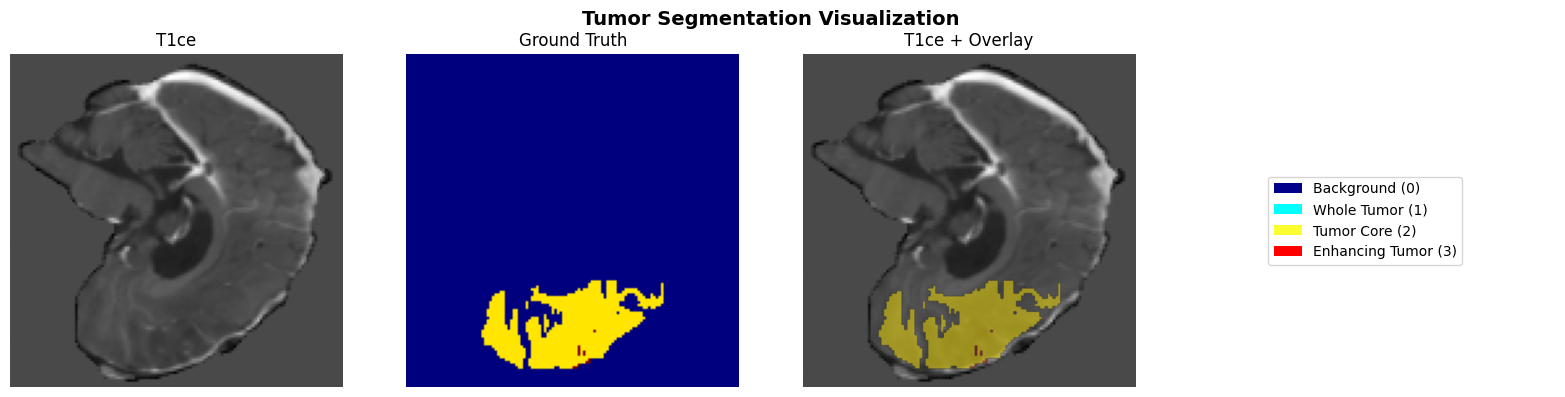

In [22]:
# Overlay segmentation on T1ce (best for tumor visualization)
if sample_files:
    # sample_data = np.load(sample_files[0])
    t1ce = SAMPLE_DATA['images'][3]  # T1ce is channel 3
    seg = SAMPLE_DATA['seg']
    
    slice_idx = find_best_slice(seg, axis=2)
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    # T1ce only
    axes[0].imshow(t1ce[slice_idx, :, :], cmap='gray')
    axes[0].set_title('T1ce', fontsize=12)
    axes[0].axis('off')
    
    # Segmentation only
    axes[1].imshow(seg[slice_idx, :, :], cmap='jet', vmin=0, vmax=3)
    axes[1].set_title('Ground Truth', fontsize=12)
    axes[1].axis('off')
    
    # Overlay
    axes[2].imshow(t1ce[slice_idx, :, :], cmap='gray')
    mask = seg[slice_idx, :, :] > 0
    axes[2].imshow(np.ma.masked_where(~mask, seg[slice_idx, :, :]), 
                   cmap='jet', alpha=0.5, vmin=0, vmax=3)
    axes[2].set_title('T1ce + Overlay', fontsize=12)
    axes[2].axis('off')
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
    Patch(facecolor='#00008B', label='Background (0)'),       # dark blue
    Patch(facecolor='#00FFFF', label='Whole Tumor (1)'),      # cyan
    Patch(facecolor="#FCFF2F", label='Tumor Core (2)'),       # yellow
    Patch(facecolor='#FF0000', label='Enhancing Tumor (3)')   # red
]
    axes[3].legend(handles=legend_elements, loc='center', fontsize=10)
    axes[3].axis('off')
    
    plt.suptitle('Tumor Segmentation Visualization', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Save for paper
    plt.savefig('/home/mci/arsyadl/mmsk/results/tumor_overlay.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: results/tumor_overlay.png")
    plt.show()

### 10.3 Multiple Samples Comparison

Samples dengan semua kelas: 555 dari 1350
✓ Saved: results/multiple_samples.png


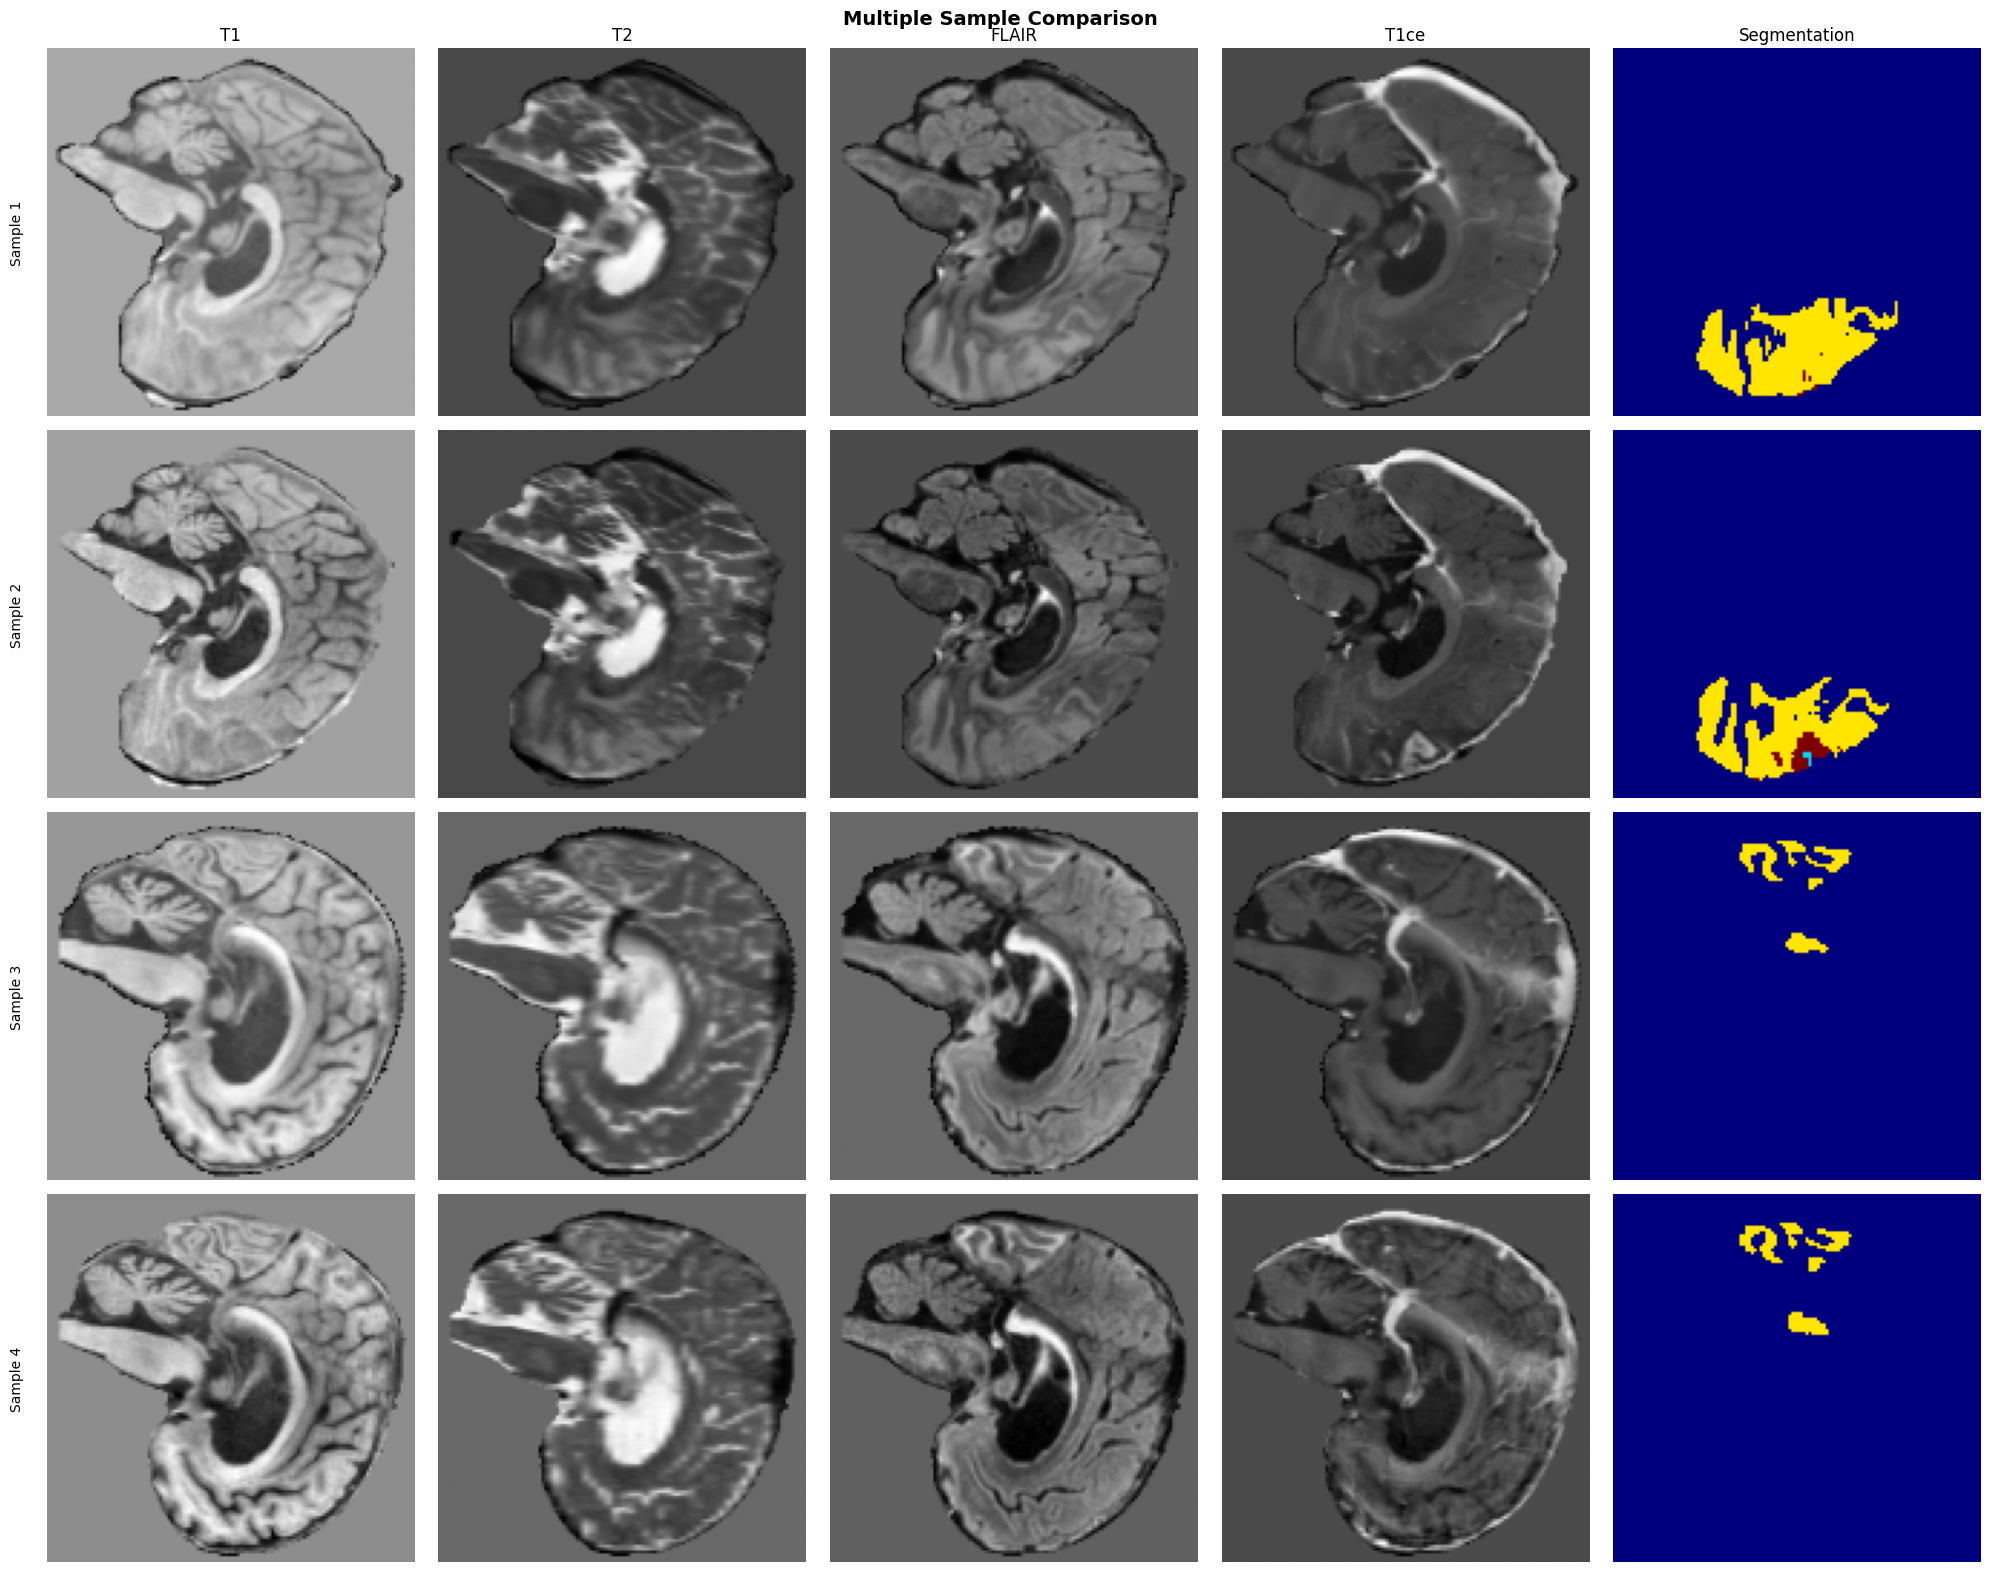

In [13]:
# Show 4 different samples
# n_samples = min(4, len(sample_files))
all_class_files = [
    f for f in sample_files
    if {0,1,2,3}.issubset(set(np.unique(np.load(f)['seg']).tolist()))
]
print(f"Samples dengan semua kelas: {len(all_class_files)} dari {len(sample_files)}")
n_samples = min(4, len(all_class_files))

fig, axes = plt.subplots(n_samples, 5, figsize=(20, 4*n_samples))

for idx in range(n_samples):
    data = np.load(all_class_files[idx])
    images = data['images']
    seg = data['seg']
    
    slice_idx = TARGET_SIZE[0] // 2
    
    # Show all modalities
    for i, name in enumerate(MODALITY_NAMES):
        axes[idx, i].imshow(images[i, slice_idx, :, :], cmap='gray')
        if idx == 0:
            axes[idx, i].set_title(name, fontsize=12)
        axes[idx, i].axis('off')
    
    # Segmentation
    axes[idx, 4].imshow(seg[slice_idx, :, :], cmap='jet', vmin=0, vmax=3)
    if idx == 0:
        axes[idx, 4].set_title('Segmentation', fontsize=12)
    axes[idx, 4].axis('off')
    
    # Sample name on left
    axes[idx, 0].text(-0.1, 0.5, f'Sample {idx+1}', 
                      transform=axes[idx, 0].transAxes,
                      fontsize=10, va='center', rotation=90)

plt.suptitle('Multiple Sample Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()

# Save for paper
plt.savefig('/home/mci/arsyadl/mmsk/results/multiple_samples.png', dpi=300, bbox_inches='tight')
print("✓ Saved: results/multiple_samples.png")
plt.show()

### 10.4 Dataset Statistics for Paper

In [14]:
# Calculate statistics across all samples
print("Calculating dataset statistics...\n")

# Sample 10 random files for statistics
import random
random.seed(42)
sample_subset = random.sample(list(sample_files), min(10, len(sample_files)))

modality_stats = {name: {'mean': [], 'std': []} for name in MODALITY_NAMES}
tumor_volumes = []

for f in tqdm(sample_subset, desc="Computing stats"):
    data = np.load(f)
    images = data['images']
    seg = data['seg']
    
    # Modality statistics
    for i, name in enumerate(MODALITY_NAMES):
        mask = images[i] != 0
        if mask.sum() > 0:
            modality_stats[name]['mean'].append(images[i][mask].mean())
            modality_stats[name]['std'].append(images[i][mask].std())
    
    # Tumor volume (percentage)
    tumor_voxels = (seg > 0).sum()
    total_voxels = seg.size
    tumor_volumes.append(tumor_voxels / total_voxels * 100)

# Print statistics
print("\n" + "="*60)
print("DATASET STATISTICS (for paper)")
print("="*60)

print("\nModality Statistics (after Z-score normalization):")
for name in MODALITY_NAMES:
    mean_avg = np.mean(modality_stats[name]['mean'])
    std_avg = np.mean(modality_stats[name]['std'])
    print(f"  {name:6s}: mean={mean_avg:6.3f} ± {np.std(modality_stats[name]['mean']):.3f}, "
          f"std={std_avg:6.3f} ± {np.std(modality_stats[name]['std']):.3f}")

print(f"\nTumor Volume Statistics:")
print(f"  Mean: {np.mean(tumor_volumes):.2f}%")
print(f"  Std:  {np.std(tumor_volumes):.2f}%")
print(f"  Min:  {np.min(tumor_volumes):.2f}%")
print(f"  Max:  {np.max(tumor_volumes):.2f}%")

print(f"\nDataset Size:")
print(f"  Training samples: {success_count}")
print(f"  Validation samples: {val_success}")
print(f"  Total: {success_count + val_success}")
print(f"  Input shape: {TARGET_SIZE}")
print(f"  Number of modalities: 4 (T1, T2, FLAIR, T1ce)")
print(f"  Number of classes: 4 (Background, WT, TC, ET)")

Calculating dataset statistics...



Computing stats: 100%|██████████| 10/10 [00:01<00:00,  9.32it/s]


DATASET STATISTICS (for paper)

Modality Statistics (after Z-score normalization):
  T1    : mean=-0.000 ± 0.000, std= 0.934 ± 0.008
  T2    : mean=-0.000 ± 0.000, std= 0.933 ± 0.012
  FLAIR : mean=-0.000 ± 0.000, std= 0.918 ± 0.012
  T1ce  : mean= 0.000 ± 0.000, std= 0.905 ± 0.012

Tumor Volume Statistics:
  Mean: 1.78%
  Std:  1.32%
  Min:  0.01%
  Max:  3.98%

Dataset Size:


NameError: name 'success_count' is not defined

## 11. Summary

In [ ]:
print("="*60)
print("PREPROCESSING SUMMARY")
print("="*60)
print(f"\nTraining Data:")
print(f"  Input: {DATA_DIR}")
print(f"  Output: {OUTPUT_DIR}")
print(f"  Samples processed: {success_count}")
print(f"\nValidation Data:")
print(f"  Input: {DATA_DIR_VAL}")
print(f"  Output: {OUTPUT_DIR_VAL}")
print(f"  Samples processed: {val_success}")
print(f"\nPreprocessing Configuration:")
print(f"  Target size: {TARGET_SIZE}")
print(f"  Modality order: {MODALITY_NAMES}")
print(f"  Normalization: Z-score (per modality, non-zero voxels)")
print(f"  Cropping: Non-zero region with margin=5")
print(f"  Resizing: scipy.ndimage.zoom")
print(f"\nOutput format:")
print(f"  - File type: .npz")
print(f"  - Keys: 'images', 'seg'")
print(f"  - images shape: [4, 128, 128, 128] (float32)")
print(f"  - seg shape: [128, 128, 128] (uint8)")
print(f"\nVisualizations saved:")
print(f"  - results/sample_visualization.png")
print(f"  - results/tumor_overlay.png")
print(f"  - results/multiple_samples.png")
print(f"\n✓ Ready for training with MMSK 3D U-Net!")
print(f"\nNext steps:")
print(f"  1. cd mmsk")
print(f"  2. python3 prepare_dataset_no_split.py")
print(f"  3. python3 train_proposed_mmsk_tversky.py")

PREPROCESSING SUMMARY

Training Data:
  Input: /home/mci/arsyadl/braTS/training_data1_v2
  Output: /home/mci/arsyadl/braTS/preprocessed
  Samples processed: 1350

Validation Data:
  Input: /home/mci/arsyadl/braTS/training_data_additional
  Output: /home/mci/arsyadl/braTS/preprocessed_test
  Samples processed: 269

Preprocessing Configuration:
  Target size: (128, 128, 128)
  Modality order: ['T1', 'T2', 'FLAIR', 'T1ce']
  Normalization: Z-score (per modality, non-zero voxels)
  Cropping: Non-zero region with margin=5
  Resizing: scipy.ndimage.zoom

Output format:
  - File type: .npz
  - Keys: 'images', 'seg'
  - images shape: [4, 128, 128, 128] (float32)
  - seg shape: [128, 128, 128] (uint8)

Visualizations saved:
  - results/sample_visualization.png
  - results/tumor_overlay.png
  - results/multiple_samples.png

✓ Ready for training with MMSK 3D U-Net!

Next steps:
  1. cd mmsk
  2. python3 prepare_dataset_no_split.py
  3. python3 train_proposed_mmsk_tversky.py
